In [19]:
import pandas as pd

positive_dataset = pd.read_csv("RHEA_enzyme_compound_pairs_sequence_smiles_filtered.csv")


In [20]:
# read fasta file with biopython

from Bio import SeqIO

fasta_sequences = SeqIO.parse(open("../clusters/all_sequences.fasta"),'fasta')
for fasta in fasta_sequences:
    if "P83379" == fasta.id:
        print(fasta.seq)
        break

FLFVGDL


In [21]:
from enzyme_substrate_prediction.etl_pipeline.cdhit_clusters import ClustersIdentifier

clust_ident_40 = ClustersIdentifier.from_files(identity_threshold=40, folder="../clusters/", filename='all_sequences')
clust_ident_80 = ClustersIdentifier.from_files(identity_threshold=80, folder="../clusters/", filename='all_sequences')
clust_ident_60 = ClustersIdentifier.from_files(identity_threshold=60, folder="../clusters/", filename='all_sequences')
clust_ident_90 = ClustersIdentifier.from_files(identity_threshold=90, folder="../clusters/", filename='all_sequences')

In [22]:
def get_members_of_cluster_for_negative_cases(clusters: ClustersIdentifier, uniprot_id: str, uniprot_ids_for_negative_cases):
    cluster = clusters.get_cluster_by_member(uniprot_id)
    uniprot_ids_for_negative_cases[uniprot_id] = cluster
    return uniprot_ids_for_negative_cases

In [23]:
uniprot_ids_for_negative_cases = {}
not_considered_sequences = []
for uniprot_id in positive_dataset.uniprot_id.unique():
    cluster = clust_ident_90.get_cluster_by_member(uniprot_id)
    if cluster is None:
        not_considered_sequences.append(uniprot_id)
    else:
        if len(cluster) > 1:
            uniprot_ids_for_negative_cases = get_members_of_cluster_for_negative_cases(clust_ident_90, uniprot_id, uniprot_ids_for_negative_cases)

        elif len(clust_ident_80.get_cluster_by_member(uniprot_id)) > 1:
            uniprot_ids_for_negative_cases = get_members_of_cluster_for_negative_cases(clust_ident_80, uniprot_id, uniprot_ids_for_negative_cases)

        elif len(clust_ident_60.get_cluster_by_member(uniprot_id)) > 1:
            uniprot_ids_for_negative_cases = get_members_of_cluster_for_negative_cases(clust_ident_60, uniprot_id, uniprot_ids_for_negative_cases)

        elif len(clust_ident_40.get_cluster_by_member(uniprot_id)) > 1:
            uniprot_ids_for_negative_cases = get_members_of_cluster_for_negative_cases(clust_ident_40, uniprot_id, uniprot_ids_for_negative_cases)

In [24]:
positive_dataset[positive_dataset.CHEBI_ID == "CHEBI:59871"].reaction_SMILES.values[0]

'*[C@@H]([NH3+])C(=O)[O-].O=O.[H]O[H]>>[1*]C(=O)C(=O)[O-].[H]OO[H].[H][N+]([H])([H])[H]'

In [25]:
rhea_id_to_uniprot_ids = {}
for rhea_id in positive_dataset.RHEA_ID.unique():
    rhea_id_to_uniprot_ids[rhea_id] = positive_dataset[positive_dataset.RHEA_ID == rhea_id].uniprot_id.unique()

In [26]:
rhea_id_to_compound_ids = {}
for rhea_id in positive_dataset.RHEA_ID.unique():
    rhea_id_to_compound_ids[rhea_id] = positive_dataset[positive_dataset.RHEA_ID == rhea_id].CHEBI_ID.unique()

In [27]:
smiles = positive_dataset.SMILES.unique()

In [28]:
chebi_ids = positive_dataset.loc[:, ["CHEBI_ID", "SMILES"]]
# select only unique CHEBI_IDs
chebi_ids = chebi_ids.drop_duplicates()
chebi_ids

,CHEBI_ID,SMILES
0,CHEBI:58413,C[NH+]1CCC[C@@H]1c1ccc(O)nc1
1,CHEBI:16353,COc1cc(/C=C/C(=O)OCC[N+](C)(C)C)cc(OC)c1O
2,CHEBI:29986,[NH3+][C@H](CCC(=O)[O-])C(=O)[O-]
3,CHEBI:57416,C[C@@H]([NH3+])C(=O)[O-]
4,CHEBI:59871,*[C@@H]([NH3+])C(=O)[O-]
...,...,...
212023,CHEBI:193561,COc1ccc([C@@]2(O)c3c(ccc(/C=C/C(C)=C/CC4OC4(C)...
212025,CHEBI:193519,*N[C@@H](COP(=O)([O-])OCC(C)(C)[C@@H](O)C(=O)N...
212026,CHEBI:324935,CO[C@@H]1[C@H](O)CC[C@]2(CO2)[C@H]1[C@@]1(C)O[...
212027,CHEBI:194488,Nc1c2sscc-2[nH]c1=O


In [29]:
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import ExplicitBitVect

def np_to_bv(fv):
    bv = ExplicitBitVect(len(fv))
    for i,v in enumerate(fv):
        if v:
            bv.SetBit(i)
    return bv


# Convert SMILES to molecular objects and compute fingerprints
mol_list = [Chem.MolFromSmiles(smiles_) for smiles_ in chebi_ids.SMILES]
fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024) for mol in mol_list]
#fps = list(fingerprints.X)

# Compute Tanimoto similarity matrix
similarity_matrix = np.zeros((len(fps), len(fps)))
for i in range(len(fps)):
    for j in range(i, len(fps)):
        #intersection = np.logical_and(fps[i], fps[j])
        #union = np.logical_or(fps[i], fps[j])

        # Calculate the Tanimoto similarity
        #similarity = np.sum(intersection) / np.sum(union)
        similarity = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

#kmean = KMeans(n_clusters=5)
#kmean.fit(similarity_matrix)


[10:14:37] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:14:37] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:14:37] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:14:37] WARNING: not removing hydrogen atom with dummy atom neighbors


In [30]:
similarity_matrix_pd = pd.DataFrame(similarity_matrix, columns=chebi_ids.CHEBI_ID, index=chebi_ids.CHEBI_ID)
similarity_matrix_pd

CHEBI_ID,CHEBI:58413,CHEBI:16353,CHEBI:29986,CHEBI:57416,CHEBI:59871,CHEBI:32557,CHEBI:29990,CHEBI:58343,CHEBI:58282,CHEBI:58339,...,CHEBI:144963,CHEBI:149594,CHEBI:149592,CHEBI:71680,CHEBI:193079,CHEBI:193561,CHEBI:193519,CHEBI:324935,CHEBI:194488,CHEBI:142976
CHEBI_ID,,,,,,,,,,,,,,,,,,,,,
CHEBI:58413,1.000000,0.114754,0.020408,0.047619,0.023256,0.040000,0.021277,0.109589,0.090909,0.100000,...,0.117647,0.095890,0.032258,0.055556,0.095238,0.084337,0.056818,0.096774,0.037736,0.079137
CHEBI:16353,0.114754,1.000000,0.098039,0.111111,0.086957,0.094340,0.102041,0.101266,0.058824,0.105882,...,0.160920,0.131579,0.093750,0.086207,0.195122,0.200000,0.125000,0.104478,0.070175,0.106383
CHEBI:29986,0.020408,0.098039,1.000000,0.391304,0.391304,0.538462,0.565217,0.078125,0.125000,0.070423,...,0.092105,0.114754,0.155556,0.153846,0.066667,0.068493,0.094595,0.056604,0.048780,0.061538
CHEBI:57416,0.047619,0.111111,0.391304,1.000000,0.529412,0.360000,0.428571,0.050000,0.111111,0.044776,...,0.084507,0.107143,0.150000,0.147059,0.072464,0.074627,0.086957,0.041667,0.057143,0.056000
CHEBI:59871,0.023256,0.086957,0.391304,0.529412,1.000000,0.360000,0.428571,0.050000,0.111111,0.044776,...,0.084507,0.107143,0.150000,0.147059,0.057143,0.058824,0.086957,0.020408,0.057143,0.047619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEBI:193561,0.084337,0.200000,0.068493,0.074627,0.058824,0.066667,0.070423,0.101010,0.070423,0.104762,...,0.108108,0.090909,0.057471,0.062500,0.714286,1.000000,0.100000,0.246753,0.092105,0.098765
CHEBI:193519,0.056818,0.125000,0.094595,0.086957,0.086957,0.077922,0.082192,0.098039,0.097222,0.101852,...,0.657895,0.144330,0.144578,0.189189,0.088496,0.100000,1.000000,0.064516,0.023810,0.292857
CHEBI:324935,0.096774,0.104478,0.056604,0.041667,0.020408,0.054545,0.058824,0.115385,0.102041,0.105882,...,0.063158,0.036145,0.029412,0.050000,0.180723,0.246753,0.064516,1.000000,0.016667,0.090909


In [31]:
# get chebi ids concatenated with uniprot ids

chebi_ids_uniprot_ids = positive_dataset.loc[:, ["CHEBI_ID", "uniprot_id"]]
chebi_ids_uniprot_ids = chebi_ids_uniprot_ids.drop_duplicates()
chebi_ids_uniprot_ids["CHEBI_ID"] = chebi_ids_uniprot_ids["CHEBI_ID"].astype(str)   
chebi_ids_uniprot_ids["uniprot_id"] = chebi_ids_uniprot_ids["uniprot_id"].astype(str)
CHEBI_ID_uniprot_id = chebi_ids_uniprot_ids["CHEBI_ID"] + "_" + chebi_ids_uniprot_ids["uniprot_id"]

In [32]:
from tqdm import tqdm
from enzyme_substrate_prediction.etl_pipeline._utils import tqdm_joblib

from joblib import Parallel, delayed


negative_cases = []

def get_negative_cases(reaction_id, positive_dataset, 
                       uniprot_ids_for_negative_cases, similarity_matrix_pd, 
                       CHEBI_ID_uniprot_id):
    
    negative_cases = []
    
    entries = positive_dataset[positive_dataset.RHEA_ID == reaction_id]
    for _, entry in entries.iterrows():
        uniprot_id = entry.uniprot_id
        chebi_id = entry.CHEBI_ID
        try:
            members = uniprot_ids_for_negative_cases[uniprot_id].member_to_other_members(uniprot_id)
            chebi_similarities = similarity_matrix_pd.loc[chebi_id, :]
            chebi_similar_compounds = chebi_similarities[chebi_similarities > 0.6]
            if len(members) > 0 and len(chebi_similar_compounds) > 0:
                for member in members:
                    for chebi_id_, similarity in chebi_similar_compounds.items():
                        pair = f"{chebi_id_}_{member}"
                        if pair not in CHEBI_ID_uniprot_id:
                            negative_cases.append([f"fake_{reaction_id}", chebi_id_, member, uniprot_ids_for_negative_cases[uniprot_id].identity_threshold, similarity])
        except KeyError:
            continue
    return negative_cases



In [34]:
negative_cases = []

bar = tqdm(total=len(positive_dataset.RHEA_ID.unique()))
for reaction_id in positive_dataset.RHEA_ID.unique():
    bar.update(1)
    negative_cases_ = get_negative_cases(reaction_id, positive_dataset, uniprot_ids_for_negative_cases, similarity_matrix_pd, CHEBI_ID_uniprot_id)
    negative_cases.extend(negative_cases_)

100%|█████████▉| 4408/4422 [02:57<00:00, 145.51it/s]

In [35]:
negative_cases = pd.DataFrame(negative_cases, columns=["RHEA_ID", "CHEBI_ID", "uniprot_id", "protein_identity_threshold", "compound_similarity"])

100%|██████████| 4422/4422 [03:08<00:00, 145.51it/s]

In [36]:
negative_cases.sort_values(by=["protein_identity_threshold", "compound_similarity"], ascending=False, inplace=True)

In [37]:
negative_cases.drop_duplicates(subset=["CHEBI_ID", "uniprot_id"], inplace=True)
negative_cases.shape

(2174856, 5)

In [38]:
negative_cases

,RHEA_ID,CHEBI_ID,uniprot_id,protein_identity_threshold,compound_similarity
44,fake_10028.0,CHEBI:29986,Q922Z0,90,1.000000
47,fake_10028.0,CHEBI:29985,Q922Z0,90,1.000000
132,fake_10028.0,CHEBI:29986,D3ZDM7,90,1.000000
135,fake_10028.0,CHEBI:29985,D3ZDM7,90,1.000000
202,fake_21816.0,CHEBI:59871,P14920,90,1.000000
...,...,...,...,...,...
37514188,fake_24404.0,CHEBI:59807,A8WG57,40,0.601504
37515658,fake_24404.0,CHEBI:59807,O34873,40,0.601504
39353123,fake_38355.0,CHEBI:140635,G3KIM3,40,0.601504
39353267,fake_38355.0,CHEBI:140635,P11569,40,0.601504


In [39]:
negative_cases["protein_identity_"] = negative_cases["protein_identity_threshold"] * 0.01
negative_cases

,RHEA_ID,CHEBI_ID,uniprot_id,protein_identity_threshold,compound_similarity,protein_identity_
44,fake_10028.0,CHEBI:29986,Q922Z0,90,1.000000,0.9
47,fake_10028.0,CHEBI:29985,Q922Z0,90,1.000000,0.9
132,fake_10028.0,CHEBI:29986,D3ZDM7,90,1.000000,0.9
135,fake_10028.0,CHEBI:29985,D3ZDM7,90,1.000000,0.9
202,fake_21816.0,CHEBI:59871,P14920,90,1.000000,0.9
...,...,...,...,...,...,...
37514188,fake_24404.0,CHEBI:59807,A8WG57,40,0.601504,0.4
37515658,fake_24404.0,CHEBI:59807,O34873,40,0.601504,0.4
39353123,fake_38355.0,CHEBI:140635,G3KIM3,40,0.601504,0.4
39353267,fake_38355.0,CHEBI:140635,P11569,40,0.601504,0.4


In [40]:
negative_cases.to_csv("negative_cases.csv", index=False)

In [41]:
import pandas as pd

negative_cases = pd.read_csv("negative_cases.csv")

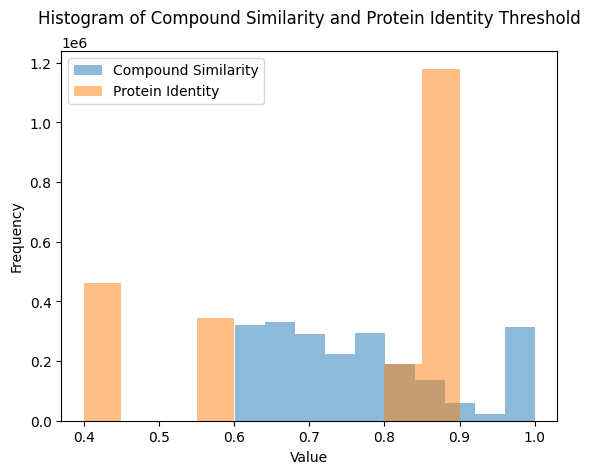

In [42]:
# Plotting overlapping histograms
fig, ax = plt.subplots()

# Define the number of bins
bins = 10

# Plot compound_similarity histogram
ax.hist(negative_cases['compound_similarity'], bins=bins, alpha=0.5, label='Compound Similarity', density=False)

# Plot protein_identity_ histogram
ax.hist(negative_cases['protein_identity_'], bins=bins, alpha=0.5, label='Protein Identity', density=False)

# Add labels, title, and legend
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Compound Similarity and Protein Identity Threshold', pad=20)
ax.legend()

plt.show()

In [43]:
datapoints = positive_dataset.shape[0]

In [44]:
def get_sample_for_negative_cases(negative_cases, number_of_data_points, percentage, protein_identity, lb_compound_similarity, up_compound_similarity):
    if lb_compound_similarity == up_compound_similarity:
        negative_cases_ = negative_cases[(negative_cases.protein_identity_threshold == protein_identity) & (negative_cases.compound_similarity == lb_compound_similarity)]
    else:
        negative_cases_ = negative_cases[(negative_cases.protein_identity_threshold == protein_identity) & (negative_cases.compound_similarity < up_compound_similarity) & (negative_cases.compound_similarity >= lb_compound_similarity)]
    return negative_cases_.sample(n=int(percentage * number_of_data_points))


In [45]:
final_negative_cases = pd.concat([get_sample_for_negative_cases(negative_cases, datapoints, 0.45, 90, 1, 1),
                                    get_sample_for_negative_cases(negative_cases, datapoints, 0.1, 90, 0.9, 1),
                                    get_sample_for_negative_cases(negative_cases, datapoints, 0.02, 80, 0.9, 1),
                                    get_sample_for_negative_cases(negative_cases, datapoints, 0.1, 80, 0.8, 0.9),
                                    get_sample_for_negative_cases(negative_cases, datapoints, 0.05, 60, 0.6, 0.8),
                                    get_sample_for_negative_cases(negative_cases, datapoints, 0.05, 40, 0.6, 0.8)])

final_negative_cases.shape

(163259, 6)

In [46]:
final_negative_cases.drop_duplicates(subset=["CHEBI_ID", "uniprot_id"], inplace=True)
final_negative_cases.shape

(163259, 6)

In [47]:
final_negative_cases_CHEBI_ID_uniprot_id = final_negative_cases["CHEBI_ID"] + "_" + final_negative_cases["uniprot_id"]
print(CHEBI_ID_uniprot_id.shape)
CHEBI_ID_uniprot_id = pd.concat((CHEBI_ID_uniprot_id, final_negative_cases_CHEBI_ID_uniprot_id))
print(CHEBI_ID_uniprot_id.shape)

(202197,)
(365456,)


In [48]:
rhea_ids_in_negative_dataset = final_negative_cases.RHEA_ID.unique()
rhea_ids_in_negative_dataset = pd.Series(rhea_ids_in_negative_dataset)

In [49]:
from numpy import float64

rhea_ids_in_negative_dataset = rhea_ids_in_negative_dataset.str.replace("fake_", "").astype(float64)

In [50]:
leftout_reactions = positive_dataset[~positive_dataset["RHEA_ID"].isin(rhea_ids_in_negative_dataset)].RHEA_ID.unique()

In [51]:
from numpy import NaN


def get_negative_cases_for_reactions_left_out(reaction_id, positive_dataset, 
                       uniprot_ids_for_negative_cases, similarity_matrix_pd, 
                       CHEBI_ID_uniprot_id):
    
    negative_cases = []
    
    entries = positive_dataset[positive_dataset.RHEA_ID == reaction_id]
    for _, entry in entries.iterrows():
        uniprot_id = entry.uniprot_id
        chebi_id = entry.CHEBI_ID
        try:
            members = uniprot_ids_for_negative_cases[uniprot_id].member_to_other_members(uniprot_id)
            if len(members) > 0:
                for member in members:
                    pair = f"{chebi_id}_{member}"
                    if pair not in CHEBI_ID_uniprot_id:
                        negative_cases.append([f"fake_{reaction_id}", chebi_id, member, uniprot_ids_for_negative_cases[uniprot_id].identity_threshold, 1])
        except KeyError:
            continue
    return negative_cases

def get_negative_cases_for_reactions_left_out_late(reaction_id, positive_dataset, 
                       uniprot_ids_for_negative_cases, similarity_matrix_pd, 
                       CHEBI_ID_uniprot_id, n_pairs_per_reaction):
    import numpy as np
    import random

    # Check for global seeds
    np.random.seed(None)
    random.seed(None)
    
    negative_cases = []
    
    entries = positive_dataset[positive_dataset.RHEA_ID == reaction_id]
    uniprot_ids = list(positive_dataset.uniprot_id.unique())
    CHEBI_ID_uniprot_id = list(CHEBI_ID_uniprot_id)
    for _, entry in entries.iterrows():
        chebi_id = entry.CHEBI_ID
        try:
            for i in range(0, n_pairs_per_reaction):
                member = random.choice(uniprot_ids)
                pair = f"{chebi_id}_{member}"
                while pair in CHEBI_ID_uniprot_id:
                    member = random.choice(uniprot_ids)
                    pair = f"{chebi_id}_{member}"
                
                negative_cases.append([f"fake_{reaction_id}", chebi_id, member, NaN, 1])
                CHEBI_ID_uniprot_id.append(pair)
                assert pair in CHEBI_ID_uniprot_id
                
        except KeyError:
            continue
    
    return negative_cases

def get_negative_cases_for_compounds_left_out(compound_id, positive_dataset, 
                       uniprot_ids_for_negative_cases, similarity_matrix_pd, 
                       CHEBI_ID_uniprot_id, n_pairs_per_reaction):
    import numpy as np
    import random

    # Check for global seeds
    np.random.seed(None)
    random.seed(None)
    
    negative_cases = []
    
    entries = positive_dataset[positive_dataset.CHEBI_ID == compound_id]
    uniprot_ids = list(positive_dataset.uniprot_id.unique())
    CHEBI_ID_uniprot_id = list(CHEBI_ID_uniprot_id)
    for _, entry in entries.iterrows():
        chebi_id = entry.CHEBI_ID
        reaction_id = entry.RHEA_ID
        try:
            for i in range(0, n_pairs_per_reaction):
                member = random.choice(uniprot_ids)
                pair = f"{chebi_id}_{member}"
                while pair in CHEBI_ID_uniprot_id:
                    member = random.choice(uniprot_ids)
                    pair = f"{chebi_id}_{member}"
                
                negative_cases.append([f"fake_{reaction_id}", chebi_id, member, NaN, 1])
                CHEBI_ID_uniprot_id.append(pair)
                assert pair in CHEBI_ID_uniprot_id
                
        except KeyError:
            continue
    
    return negative_cases

In [52]:
from tqdm import tqdm 

negative_cases_leftout_reactions = []
bar = tqdm(total=len(leftout_reactions))
bar.reset()
for reaction in leftout_reactions:
    bar.update(1)
    negative_cases_ = get_negative_cases_for_reactions_left_out(reaction, positive_dataset, uniprot_ids_for_negative_cases, similarity_matrix_pd, CHEBI_ID_uniprot_id)
    negative_cases_leftout_reactions.extend(negative_cases_)

negative_cases_leftout_reactions = pd.DataFrame(negative_cases_leftout_reactions, columns=["RHEA_ID", "CHEBI_ID", "uniprot_id", "protein_identity_threshold", "compound_similarity"])
from numpy import float64

rhea_ids_in_negative_dataset_2 = negative_cases_leftout_reactions.RHEA_ID.unique()
rhea_ids_in_negative_dataset_2 = pd.Series(rhea_ids_in_negative_dataset_2)
rhea_ids_in_negative_dataset_2 = rhea_ids_in_negative_dataset_2.str.replace("fake_", "").astype(float64)
rhea_ids_in_negative_dataset_2 = pd.concat((rhea_ids_in_negative_dataset, pd.Series(rhea_ids_in_negative_dataset_2)))
leftout_reactions_2 = positive_dataset[~positive_dataset["RHEA_ID"].isin(rhea_ids_in_negative_dataset_2)].RHEA_ID.unique()
leftout_reactions_2.shape


100%|██████████| 4422/4422 [03:37<00:00, 20.29it/s] 


(680,)

In [59]:
negative_cases_leftout_reactions

,RHEA_ID,CHEBI_ID,uniprot_id,protein_identity_threshold,compound_similarity
0,fake_10016.0,CHEBI:16353,P0C8Z7,80,1
1,fake_10016.0,CHEBI:16353,Q3E7I6,80,1
2,fake_10016.0,CHEBI:16353,Q9FPE4,80,1
3,fake_10016.0,CHEBI:16353,Q38894,80,1
4,fake_10184.0,CHEBI:58425,Q59093,40,1
...,...,...,...,...,...
93076,fake_62680.0,CHEBI:133763,Q4WQY7,40,1
93077,fake_62680.0,CHEBI:133763,E9F647,60,1
93078,fake_74491.0,CHEBI:193079,P9WEP9,40,1
93079,fake_74495.0,CHEBI:193079,G2X4M1,40,1


In [53]:
final_negative_cases_CHEBI_ID_uniprot_id = negative_cases_leftout_reactions["CHEBI_ID"] + "_" + negative_cases_leftout_reactions["uniprot_id"]
print(CHEBI_ID_uniprot_id.shape)
CHEBI_ID_uniprot_id = pd.concat((CHEBI_ID_uniprot_id, final_negative_cases_CHEBI_ID_uniprot_id))
print(CHEBI_ID_uniprot_id.shape)

(365456,)
(458537,)


In [54]:
rhea_ids_in_negative_dataset_2.shape

(3742,)

In [55]:
from tqdm import tqdm 

negative_cases_leftout_reactions_late = []
bar = tqdm(total=len(leftout_reactions_2))
bar.reset()
for reaction in leftout_reactions_2:
    bar.update(1)
    negative_cases_ = get_negative_cases_for_reactions_left_out_late(reaction, positive_dataset, uniprot_ids_for_negative_cases, 
                                                                     similarity_matrix_pd, CHEBI_ID_uniprot_id, 10)
    negative_cases_leftout_reactions_late.extend(negative_cases_)

negative_cases_leftout_reactions_late = pd.DataFrame(negative_cases_leftout_reactions_late, columns=["RHEA_ID", "CHEBI_ID", "uniprot_id", "protein_identity_threshold", "compound_similarity"])

rhea_ids_in_negative_dataset_3 = negative_cases_leftout_reactions_late.RHEA_ID.unique()
rhea_ids_in_negative_dataset_3 = pd.Series(rhea_ids_in_negative_dataset_3)
rhea_ids_in_negative_dataset_3 = rhea_ids_in_negative_dataset_3.str.replace("fake_", "").astype(float64)
rhea_ids_in_negative_dataset_3 = pd.concat((rhea_ids_in_negative_dataset_2, pd.Series(rhea_ids_in_negative_dataset_3)))
leftout_reactions_3 = positive_dataset[~positive_dataset["RHEA_ID"].isin(rhea_ids_in_negative_dataset_3)].RHEA_ID.unique()
leftout_reactions_3.shape

  0%|          | 0/680 [00:00<?, ?it/s]

100%|██████████| 680/680 [02:31<00:00,  4.66it/s]

(0,)

In [60]:
negative_cases_leftout_reactions_late

,RHEA_ID,CHEBI_ID,uniprot_id,protein_identity_threshold,compound_similarity
0,fake_10012.0,CHEBI:58413,Q9KQ92,NaN,1
1,fake_10012.0,CHEBI:58413,Q03B02,NaN,1
2,fake_10012.0,CHEBI:58413,B2IGZ5,NaN,1
3,fake_10012.0,CHEBI:58413,A4TPK3,NaN,1
4,fake_10012.0,CHEBI:58413,Q9TUI1,NaN,1
...,...,...,...,...,...
9475,fake_75895.0,CHEBI:142976,Q43147,NaN,1
9476,fake_75895.0,CHEBI:142976,B1JRC5,NaN,1
9477,fake_75895.0,CHEBI:142976,A9CSZ1,NaN,1
9478,fake_75895.0,CHEBI:142976,P07014,NaN,1


In [ ]:
final_negative_cases

,RHEA_ID,CHEBI_ID,uniprot_id,protein_identity_threshold,compound_similarity,protein_identity_
25681,fake_24216.0,CHEBI:15894,P47740,90,1.000000,0.9
21955,fake_24793.0,CHEBI:29985,A4G0J7,90,1.000000,0.9
90240,fake_10932.0,CHEBI:29990,Q7VTJ9,90,1.000000,0.9
98615,fake_12540.0,CHEBI:57416,A7FLR7,90,1.000000,0.9
8426,fake_17989.0,CHEBI:29999,Q9Z2A0,90,1.000000,0.9
...,...,...,...,...,...,...
1886889,fake_28386.0,CHEBI:70757,Q8CPK7,40,0.712871,0.4
1848531,fake_19385.0,CHEBI:46398,P26205,40,0.745763,0.4
1954548,fake_37743.0,CHEBI:60392,Q9KYP1,40,0.666667,0.4
1836136,fake_16105.0,CHEBI:76410,Q0TLV3,40,0.757009,0.4


In [ ]:
positive_dataset.shape

(208418, 7)

In [ ]:
170899/208418

0.8199819593317276

In [57]:
negative_cases_leftout_reactions_ = negative_cases_leftout_reactions.sample(int(0.12*positive_dataset.shape[0]))

In [ ]:
final_negative_cases_2 = pd.concat((negative_cases_leftout_reactions_late, final_negative_cases, negative_cases_leftout_reactions_))

In [ ]:
final_negative_cases_2

,RHEA_ID,CHEBI_ID,uniprot_id,protein_identity_threshold,compound_similarity,protein_identity_
0,fake_10012.0,CHEBI:58413,Q6QA32,NaN,1.0,NaN
1,fake_10012.0,CHEBI:58413,A8EZQ5,NaN,1.0,NaN
2,fake_10012.0,CHEBI:58413,Q6HFF0,NaN,1.0,NaN
3,fake_10012.0,CHEBI:58413,P36005,NaN,1.0,NaN
4,fake_10012.0,CHEBI:58413,B7KVV7,NaN,1.0,NaN
...,...,...,...,...,...,...
57599,fake_43332.0,CHEBI:74411,Q57LI4,90.0,1.0,NaN
22972,fake_11096.0,CHEBI:57642,A0AK48,90.0,1.0,NaN
16613,fake_11096.0,CHEBI:57642,A5CE97,90.0,1.0,NaN
35843,fake_24825.0,CHEBI:128753,Q822D9,90.0,1.0,NaN


In [ ]:
leftout_compounds = positive_dataset[~positive_dataset["CHEBI_ID"].isin(final_negative_cases_2.CHEBI_ID)].CHEBI_ID.unique()
in_compounds = positive_dataset[positive_dataset["CHEBI_ID"].isin(final_negative_cases_2.CHEBI_ID)].CHEBI_ID.unique()
leftout_compounds.shape

(218,)

In [ ]:
from tqdm import tqdm 

negative_cases_leftout_compounds = []
bar = tqdm(total=len(leftout_compounds))
bar.reset()
for compound in leftout_compounds:
    bar.update(1)
    negative_cases_ = get_negative_cases_for_compounds_left_out(compound, positive_dataset, uniprot_ids_for_negative_cases, 
                                                                     similarity_matrix_pd, CHEBI_ID_uniprot_id, 10)
    negative_cases_leftout_compounds.extend(negative_cases_)

negative_cases_leftout_compounds = pd.DataFrame(negative_cases_leftout_compounds, columns=["RHEA_ID", "CHEBI_ID", "uniprot_id", "protein_identity_threshold", "compound_similarity"])

chebi_ids_in_negative_dataset = negative_cases_leftout_compounds.CHEBI_ID.unique()
chebi_ids_in_negative_dataset = pd.Series(chebi_ids_in_negative_dataset)
chebi_ids_in_negative_dataset = pd.concat((chebi_ids_in_negative_dataset, pd.Series(in_compounds)))
leftout_compounds_2 = positive_dataset[~positive_dataset["CHEBI_ID"].isin(chebi_ids_in_negative_dataset)].RHEA_ID.unique()
leftout_compounds_2.shape

100%|██████████| 218/218 [01:17<00:00,  3.46it/s]

(0,)

In [ ]:
final_negative_cases_2 = pd.concat((final_negative_cases_2, negative_cases_leftout_compounds))

In [ ]:
rhea_chebi = pd.read_csv("rhea-chebi-smiles.tsv", sep="\t", header=None)
rhea_chebi.columns = ["CHEBI_ID", "SMILES"]
rhea_chebi.drop_duplicates(inplace=True)

df_RHEA_smiles = pd.merge(final_negative_cases_2, rhea_chebi, on = "CHEBI_ID", how = "inner")

swiss_prot_enzymes = pd.read_csv("swiss_prot_enzymes.csv")
swiss_prot_enzymes.drop(["name", "enzyme"], axis=1, inplace=True)
swiss_prot_enzymes.columns = ["uniprot_id", "sequence"]

df_RHEA_smiles_sequences = pd.merge(df_RHEA_smiles, swiss_prot_enzymes, on = "uniprot_id", how = "inner")

In [ ]:
positive_dataset.CHEBI_ID.unique().shape

(2645,)

In [ ]:
df_RHEA_smiles_sequences.CHEBI_ID.unique().shape

(2645,)

In [ ]:
df_RHEA_smiles_sequences.shape

(198428, 8)

In [ ]:
positive_dataset.RHEA_ID.unique()

array([10012., 10016., 10028., ..., 70807., 73415., 74463.])

In [ ]:
negative_cases_leftout_reactions_late.RHEA_ID.unique()

array(['fake_10012.0', 'fake_10092.0', 'fake_10288.0', 'fake_10424.0',
       'fake_10432.0', 'fake_10700.0', 'fake_10848.0', 'fake_11536.0',
       'fake_12192.0', 'fake_13029.0', 'fake_13173.0', 'fake_13325.0',
       'fake_13957.0', 'fake_14025.0', 'fake_14157.0', 'fake_14301.0',
       'fake_14517.0', 'fake_62412.0', 'fake_36307.0', 'fake_62416.0',
       'fake_15141.0', 'fake_27958.0', 'fake_15681.0', 'fake_16217.0',
       'fake_18341.0', 'fake_16309.0', 'fake_19353.0', 'fake_17209.0',
       'fake_17885.0', 'fake_18261.0', 'fake_18385.0', 'fake_19693.0',
       'fake_20057.0', 'fake_20689.0', 'fake_21568.0', 'fake_22548.0',
       'fake_22652.0', 'fake_22832.0', 'fake_22908.0', 'fake_23092.0',
       'fake_23304.0', 'fake_23604.0', 'fake_23608.0', 'fake_24844.0',
       'fake_26019.0', 'fake_26068.0', 'fake_26168.0', 'fake_26213.0',
       'fake_26514.0', 'fake_26542.0', 'fake_27385.0', 'fake_27870.0',
       'fake_28130.0', 'fake_28166.0', 'fake_28210.0', 'fake_28334.0',
      

In [ ]:
# get max, min, percentiles etc of frequencies of fake reactions contained in RHEA_ID field
negative_cases.RHEA_ID.value_counts().describe()

count     3222.000000
mean       635.759777
std       3026.981570
min          1.000000
25%          8.000000
50%         35.000000
75%        168.000000
max      80016.000000
Name: RHEA_ID, dtype: float64

In [62]:
import pandas as pd

pd.read_csv("RHEA_negative_cases_with_sequences_smiles.csv")

,RHEA_ID,CHEBI_ID,uniprot_id,protein_identity_threshold,compound_similarity,protein_identity_,SMILES,sequence
0,fake_10012.0,CHEBI:58413,Q0HKU9,NaN,1.0,NaN,C[NH+]1CCC[C@@H]1c1ccc(O)nc1,MEIIRGAPALSTFRVQKLMEACVNAALPVRQIYAEYVHLADLSELL...
1,fake_10092.0,CHEBI:131705,Q0HKU9,NaN,1.0,NaN,*[C@H]1C[C@H](OP(=O)([O-])[O-])[C@@H](CO)O1,MEIIRGAPALSTFRVQKLMEACVNAALPVRQIYAEYVHLADLSELL...
2,fake_10184.0,CHEBI:58425,Q0HKU9,NaN,1.0,NaN,O=C([O-])CC1=CCC(=O)O1,MEIIRGAPALSTFRVQKLMEACVNAALPVRQIYAEYVHLADLSELL...
3,fake_10288.0,CHEBI:17937,Q0HKU9,NaN,1.0,NaN,C[C@H](O)[C@@H]1OC(=O)[C@H](O)[C@@H]1O,MEIIRGAPALSTFRVQKLMEACVNAALPVRQIYAEYVHLADLSELL...
4,fake_50248.0,CHEBI:57967,Q0HKU9,NaN,1.0,NaN,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])OP(=O...,MEIIRGAPALSTFRVQKLMEACVNAALPVRQIYAEYVHLADLSELL...
...,...,...,...,...,...,...,...,...
209918,fake_62680.0,CHEBI:133763,A0A2I1C3W7,40.0,1.0,NaN,CC1(O)CC(=O)c2c(cc3cc(O)cc(O)c3c2O)O1,MASSTHPEMPELSGSYENKYLCLTICGYRKAGMTEEDYHNHMVHIS...
209919,fake_62680.0,CHEBI:133763,A0A4P8DJD9,40.0,1.0,NaN,CC1(O)CC(=O)c2c(cc3cc(O)cc(O)c3c2O)O1,MSVLNESEALAPSFSTKDKYLCLTICGYRKPGMSEGDYRNHMVNVS...
209920,fake_62680.0,CHEBI:133763,M1W271,40.0,1.0,NaN,CC1(O)CC(=O)c2c(cc3cc(O)cc(O)c3c2O)O1,MKMGMAKHSPRNKEYLCLTICGYRKEGMSEEAYRNHMVNVSAPMTK...
209921,fake_62680.0,CHEBI:133763,Q4WQY7,40.0,1.0,NaN,CC1(O)CC(=O)c2c(cc3cc(O)cc(O)c3c2O)O1,MGESSRKPSRYLCLTICGYRKPGMSEEDYRRYMTEVSAPMTKDLMV...
